# ĐỒ ÁN: DỰ ĐOÁN CHẤT LƯỢNG KHÔNG KHÍ TẠI VIỆT NAM VÀ CẢNH BÁO SỨC KHỎE
**Nhóm sinh viên:** Nhóm 11  
**Bộ dữ liệu:** Dữ liệu Chất lượng không khí & Khí tượng tại Hà Nội, TP.HCM, Đà Nẵng 

---

## Mục lục
- [1. Giới thiệu bài toán & Phương pháp thu thập dữ liệu](#1)
  - [1.1 Giới thiệu bài toán](#1-1)
  - [1.2 Nguồn dữ liệu](#1-2)
  - [1.3 Phương pháp thu thập dữ liệu](#1-3)
  - [1.4 Lưu trữ và quản lý dữ liệu](#1-4)
- [2. Làm sạch và Tiền xử lý dữ liệu bước đầu](#2)
  - [2.1 Load & Mô tả Dataset](#2-1)
  - [2.2 Thống kê mô tả](#2-2)
  - [2.3 Xử lý Missing Values & Trùng lặp](#2-3)
  - [2.4 Chuyển đổi kiểu dữ liệu & Kiểm tra sự nhất quán](#2-4)
  - [2.5 Đảm bảo chất lượng dữ liệu](#2-5)
- [3. Phân tích Khám phá Dữ liệu (EDA)](#3)
  - [3.1 Phân bố dữ liệu theo từng thuộc tính](#3-1)
  - [3.2 Phân tích phân bố nhãn](#3-2)
  - [3.3 Phân tích tương quan & Đa cộng tuyến](#3-3)
  - [3.4 Kiểm tra chất lượng dữ liệu và ngoại lệ](#3-4)
  - [3.5 EDA cho dữ liệu phi cấu trúc](#3-5)
- [4. Tiền xử lý dữ liệu cho Mô hình Học máy](#4)
  - [4.1 Feature Engineering & Encode Categorical](#4-1)
  - [4.2 Train/Val/Test Split (Time-Series Split)](#4-2)
  - [4.3 Chuẩn hóa (Scaling)](#4-3)


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os

from utils import *
warnings.filterwarnings('ignore')

# Cấu hình biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = '../data/processed/all_cities.csv'
print('Import thư viện thành công!')

Import thư viện thành công!


---

<a id='1'></a>
## 1. Giới thiệu bài toán & Phương pháp thu thập dữ liệu

<a id='1-1'></a>
### 1.1 Giới thiệu bài toán
Ô nhiễm không khí đang là vấn đề nghiêm trọng tại các đô thị lớn. Đề tài hướng tới việc xây dựng mô hình học máy giải quyết đồng thời hai bài toán:
1. **Hồi quy (Regression):** Dự đoán giá trị AQI cụ thể trong 24-48 giờ tới.
2. **Phân lớp (Classification):** Xác định mức chất lượng không khí (Tốt / Trung bình / Kém / Xấu / Nguy hại) để đưa ra cảnh báo sức khỏe.

<a id='1-2'></a>
### 1.2 Nguồn dữ liệu
Dữ liệu được thu thập từ **API công khai**, không sử dụng khảo sát thủ công và không scrape nội dung HTML từ website.

| Hạng mục yêu cầu | Cách thực hiện trong đề tài |
|---|---|
| Dataset có sẵn? | Không dùng dataset tải sẵn. Nhóm tự thu thập dữ liệu theo giờ bằng API cho 3 thành phố. |
| Có mở rộng dữ liệu không? | Có. Dữ liệu chất lượng không khí được merge với dữ liệu khí tượng; sau đó tạo thêm biến thời gian, mùa, lag và rolling mean. |
| Từ API? | Có. Sử dụng Open-Meteo Air Quality API và Open-Meteo Historical Weather API. |
| Web scraping? | Không. Không crawl HTML; chỉ gọi API có cấu trúc. |
| Khảo sát/biểu mẫu? | Không. Không dùng Google Form, Survey hay dữ liệu tự khai báo. |

**Hai nguồn API chính:**
* **[Open-Meteo Air Quality API](https://open-meteo.com/en/docs/air-quality-api):** dữ liệu lịch sử chất lượng không khí theo giờ gồm PM2.5, PM10, O3, NO2, SO2, CO, EU AQI và US AQI.
* **[Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api):** dữ liệu khí tượng theo giờ gồm nhiệt độ, độ ẩm, gió, mưa, áp suất và độ che phủ mây.

**Phạm vi dữ liệu thực tế trong file `all_cities.csv`:** 98,187 mẫu, 34 thuộc tính, từ `2022-08-05 07:00:00` đến `2026-04-29 23:00:00` cho Hà Nội, TP.HCM và Đà Nẵng.


<a id='1-3'></a>
### 1.3 Phương pháp thu thập dữ liệu

#### Quy trình thực hiện từng bước
Dữ liệu được thu thập tự động thông qua script `main.py` với quy trình 3 bước:

**Bước 1 - Thu thập dữ liệu chất lượng không khí**
- Gọi API `https://air-quality-api.open-meteo.com/v1/air-quality` cho từng thành phố.
- Truyền tọa độ, `start_date`, `end_date`, danh sách biến theo giờ và timezone `Asia/Ho_Chi_Minh`.
- Thu thập các biến: `pm2_5`, `pm10`, `ozone`, `nitrogen_dioxide`, `sulphur_dioxide`, `carbon_monoxide`, `european_aqi`, `us_aqi`.
- Loại bỏ các dòng thiếu PM2.5 hoặc AQI ngay tại bước thu thập.
- Lưu từng file thô: `data/raw/airquality_<city>.csv`.

**Bước 2 - Thu thập dữ liệu khí tượng**
- Gọi API `https://archive-api.open-meteo.com/v1/archive` cho cùng tọa độ và khoảng thời gian.
- Thu thập các biến: `temperature_2m`, `relative_humidity_2m`, `wind_speed_10m`, `wind_direction_10m`, `precipitation`, `surface_pressure`, `cloud_cover`.
- Lưu từng file thô: `data/raw/weather_<city>.csv`.

**Bước 3 - Ghép dữ liệu và tạo thuộc tính mới**
- Ghép Air Quality và Weather theo `datetime` bằng `pd.merge(..., how='inner')`.
- Tạo biến thời gian: `year`, `month`, `day`, `hour`, `day_of_week`, `is_weekend`, `day_of_year`, `season`.
- Tạo lag features: `pm25_lag_1h`, `pm25_lag_3h`, `pm25_lag_6h`, `pm25_lag_12h`, `pm25_lag_24h`.
- Tạo rolling features: `pm25_roll_6h`, `pm25_roll_24h`, `pm25_roll_72h`.
- Tạo nhãn phân loại AQI: `aqi_category`.
- Hợp nhất 3 thành phố thành `data/processed/all_cities.csv`.

#### Công cụ sử dụng

| Công cụ/Thư viện | Mục đích |
|---|---|
| `openmeteo-requests` | Gọi Open-Meteo API |
| `requests-cache` | Cache kết quả API để tránh gọi lặp lại |
| `retry-requests` | Tự động retry khi request lỗi |
| `pandas` | Đọc, lưu, merge và xử lý dữ liệu bảng |
| `numpy` | Tính toán số học |

#### Định dạng lưu trữ
- **Định dạng file:** CSV.
- **Encoding:** `utf-8-sig` để hỗ trợ tiếng Việt có dấu.
- **Tần suất dữ liệu:** theo giờ.
- **Múi giờ:** `Asia/Ho_Chi_Minh`.


<a id='1-4'></a>
### 1.4 Lưu trữ và quản lý dữ liệu

Dữ liệu được quản lý theo nguyên tắc tách riêng dữ liệu thô và dữ liệu đã xử lý để dễ kiểm tra, tái lập và mở rộng.

```text
data/
  raw/
    airquality_hanoi.csv
    airquality_hochiminh.csv
    airquality_danang.csv
    weather_hanoi.csv
    weather_hochiminh.csv
    weather_danang.csv
  processed/
    merged_hanoi.csv
    merged_hochiminh.csv
    merged_danang.csv
    all_cities.csv
```

| Thư mục/File | Vai trò |
|---|---|
| `data/raw/` | Lưu dữ liệu lấy trực tiếp từ API, tách theo nguồn và thành phố. Các file này được giữ lại để đối chiếu khi cần. |
| `data/processed/merged_<city>.csv` | Dữ liệu Air Quality và Weather đã merge theo `datetime` cho từng thành phố. |
| `data/processed/all_cities.csv` | File hợp nhất cuối cùng dùng cho EDA và huấn luyện mô hình. |
| `.aq_cache`, `.weather_cache` | Cache cục bộ của request API, giúp tái chạy script nhanh hơn và hạn chế gọi API lặp lại. |

Cách đặt tên file thống nhất theo mẫu `<nguồn>_<city>.csv` và `merged_<city>.csv`, giúp truy vết được dữ liệu đến từ nguồn nào, thành phố nào và đang ở giai đoạn thô hay đã xử lý.


---

<a id='2'></a>
## 2. Làm sạch và Tiền xử lý dữ liệu bước đầu

<a id='2-1'></a>
### 2.1 Load & Mô tả Dataset
**Dataset:** Dữ liệu tổng hợp về chất lượng không khí và khí tượng tại Hà Nội, TP.HCM, Đà Nẵng theo từng giờ, từ `2022-08-05 07:00:00` đến `2026-04-29 23:00:00`.

| STT | Feature | Kiểu dữ liệu | Mô tả |
|---|---|---|---|
| 1 | `datetime` | object | Thời gian quan trắc, sau đó chuyển sang `datetime64[ns]` |
| 2 | `pm25` | float64 | Nồng độ bụi mịn PM2.5 (µg/m³) |
| 3 | `pm10` | float64 | Nồng độ bụi PM10 (µg/m³) |
| 4 | `o3` | float64 | Nồng độ khí Ozone (µg/m³) |
| 5 | `no2` | float64 | Nồng độ khí Nitơ dioxide (µg/m³) |
| 6 | `so2` | float64 | Nồng độ khí Lưu huỳnh dioxide (µg/m³) |
| 7 | `co` | float64 | Nồng độ khí Carbon monoxide (µg/m³) |
| 8 | `eu_aqi` | float64 | Chỉ số AQI theo tiêu chuẩn châu Âu |
| 9 | `aqi` | float64 | Chỉ số AQI theo tiêu chuẩn US EPA, dùng làm biến mục tiêu hồi quy |
| 10 | `city` | object | Thành phố quan trắc: Hà Nội, TP.HCM, Đà Nẵng |
| 11 | `temp` | float64 | Nhiệt độ không khí (°C) |
| 12 | `humidity` | float64 | Độ ẩm không khí (%) |
| 13 | `wind_speed` | float64 | Tốc độ gió |
| 14 | `wind_dir` | float64 | Hướng gió (0-360 độ) |
| 15 | `precip` | float64 | Lượng mưa (mm) |
| 16 | `pressure` | float64 | Áp suất khí quyển (hPa) |
| 17 | `cloud_cover` | float64 | Độ che phủ mây (%) |
| 18-24 | `year`, `month`, `day`, `hour`, `day_of_week`, `is_weekend`, `day_of_year` | int64 | Thuộc tính thời gian được trích xuất từ `datetime` |
| 25 | `season` | object | Mùa hoặc mùa khí hậu theo thành phố: Xuân, Hạ, Thu, Đông, Khô, Mưa |
| 26-30 | `pm25_lag_*h` | float64 | Nồng độ PM2.5 ở các thời điểm trước đó |
| 31-33 | `pm25_roll_*h` | float64 | Trung bình trượt PM2.5 trong 6h, 24h, 72h |
| 34 | `aqi_category` | object | Nhãn phân loại AQI: Tốt, Trung bình, Kém, Xấu, Rất xấu, Nguy hại nếu xuất hiện |


Tiến hành đọc file `all_cities.csv` từ thư mục `data/processed/`.

In [43]:
df = load_data(DATA_PATH)

# Chuyển đổi cột datetime sang định dạng chuẩn của Pandas
df['datetime'] = pd.to_datetime(df['datetime'])

print(f"Kích thước bộ dữ liệu: {df.shape}")
display(df.head())

  Dataset loaded: ../data/processed/all_cities.csv
  Số mẫu (rows)     : 98,187
  Số features (cols): 34

  Kiểu dữ liệu:
    datetime                            object      
    pm25                                float64     
    pm10                                float64     
    o3                                  float64     
    no2                                 float64     
    so2                                 float64     
    co                                  float64     
    eu_aqi                              float64     
    aqi                                 float64     
    city                                object      
    temp                                float64     
    humidity                            float64     
    wind_speed                          float64     
    wind_dir                            float64     
    precip                              float64     
    pressure                            float64     
    cloud_cover               

,datetime,pm25,pm10,o3,no2,so2,co,eu_aqi,aqi,city,...,season,pm25_lag_1h,pm25_lag_3h,pm25_lag_6h,pm25_lag_12h,pm25_lag_24h,pm25_roll_6h,pm25_roll_24h,pm25_roll_72h,aqi_category
0,2022-08-05 07:00:00,20.3,29.0,44.0,17.30,8.10,345.0,72.503334,112.822914,Hà Nội,...,Hạ,NaN,NaN,NaN,NaN,NaN,20.299999,20.299999,20.299999,Kém
1,2022-08-05 08:00:00,17.2,24.7,54.0,17.95,9.70,372.0,71.836670,110.739586,Hà Nội,...,Hạ,20.3,NaN,NaN,NaN,NaN,18.750000,18.750000,18.750000,Kém
2,2022-08-05 09:00:00,17.8,25.5,68.0,18.85,11.95,410.0,71.409996,109.406260,Hà Nội,...,Hạ,17.2,NaN,NaN,NaN,NaN,18.433333,18.433333,18.433333,Kém
3,2022-08-05 10:00:00,20.4,29.1,87.0,20.00,14.70,456.0,70.913330,107.854164,Hà Nội,...,Hạ,17.8,20.3,NaN,NaN,NaN,18.925000,18.925000,18.925000,Kém
4,2022-08-05 11:00:00,22.2,31.8,98.0,20.40,15.85,476.0,70.430000,106.343760,Hà Nội,...,Hạ,20.4,17.2,NaN,NaN,NaN,19.580000,19.580000,19.580000,Kém


<a id='2-2'></a>
### 2.2 Thống kê mô tả

Mục tiêu của bước này là kiểm tra số lượng mẫu, số thuộc tính, tỷ lệ dữ liệu thiếu và các thống kê cơ bản như mean, median, variance, min/max, Q1, Q3 và IQR cho các biến số.


In [44]:
numerical_cols = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temp', 'humidity', 'wind_speed', 'precip', 'pressure', 'aqi']

# Tổng quan kích thước và missing rate trước khi làm sạch chi tiết
overview = pd.DataFrame({
    'Chỉ số': ['Số lượng mẫu', 'Số thuộc tính', 'Tổng ô dữ liệu', 'Tổng ô thiếu', 'Tỷ lệ ô thiếu (%)'],
    'Giá trị': [
        f'{df.shape[0]:,}',
        f'{df.shape[1]:,}',
        f'{df.shape[0] * df.shape[1]:,}',
        f'{df.isnull().sum().sum():,}',
        round(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 4)
    ]
})
display(overview)

# Bảng thống kê mô tả mở rộng
numeric_profile = pd.DataFrame({
    'count': df[numerical_cols].count(),
    'missing_count': df[numerical_cols].isnull().sum(),
    'missing_rate_%': (df[numerical_cols].isnull().mean() * 100),
    'mean': df[numerical_cols].mean(),
    'median': df[numerical_cols].median(),
    'variance': df[numerical_cols].var(),
    'min': df[numerical_cols].min(),
    'q1': df[numerical_cols].quantile(0.25),
    'q3': df[numerical_cols].quantile(0.75),
    'max': df[numerical_cols].max(),
    'iqr': df[numerical_cols].quantile(0.75) - df[numerical_cols].quantile(0.25),
    'skewness': df[numerical_cols].skew()
}).round(3)
display(numeric_profile)


,Chỉ số,Giá trị
0,Số lượng mẫu,"98,187"
1,Số thuộc tính,34
2,Tổng ô dữ liệu,"3,338,358"
3,Tổng ô thiếu,138
4,Tỷ lệ ô thiếu (%),0.0041


,count,missing_count,missing_rate_%,mean,median,variance,min,q1,q3,max,iqr,skewness
pm25,98187,0,0.0,30.095,23.900,478.194,0.300,16.000,36.800,232.800,20.800,2.256
pm10,98187,0,0.0,39.606,32.800,700.860,0.400,22.100,48.350,291.500,26.250,2.102
o3,98187,0,0.0,78.262,70.000,2926.987,-1.000,38.000,108.000,418.000,70.000,1.113
no2,98187,0,0.0,21.375,15.200,386.121,0.000,6.150,31.300,170.350,25.150,1.503
so2,98187,0,0.0,17.249,14.800,195.003,0.000,5.400,25.200,104.600,19.800,1.105
co,98187,0,0.0,565.584,449.000,181836.408,59.000,307.000,674.000,5784.000,367.000,3.049
temp,98187,0,0.0,25.967,26.150,19.471,6.500,23.900,28.650,41.150,4.750,-0.512
humidity,98187,0,0.0,79.664,83.098,201.776,21.568,71.454,90.959,100.000,19.505,-0.971
wind_speed,98187,0,0.0,8.864,7.989,26.360,0.000,5.082,11.755,60.716,6.674,1.134
precip,98187,0,0.0,0.266,0.000,1.206,0.000,0.000,0.100,41.900,0.100,9.459


**Nhận xét:**
- Bộ dữ liệu có 98,187 mẫu và 34 thuộc tính, đủ lớn cho các mô hình học máy cơ bản.
- Tỷ lệ missing ban đầu rất thấp; các missing chủ yếu đến từ biến lag ở đầu chuỗi thời gian.
- `pm25`, `pm10`, `co` và `precip` lệch phải, cho thấy các đợt ô nhiễm hoặc mưa lớn xuất hiện ít nhưng có giá trị cao.
- `o3` có một số giá trị âm trước xử lý, đây là dữ liệu bất hợp lý cần chuyển thành `NaN` trước khi impute.


<a id='2-3'></a>
### 2.3 Xử lý Missing Values & Trùng lặp (Duplicates)
* Kiểm tra số lượng dòng trùng lặp do lỗi thu thập từ API.
* Xử lí giá trị âm trong `o3`
* Đánh giá tỷ lệ dữ liệu thiếu ở các cảm biến đo chất lượng không khí (PM2.5, PM10,...) và khí tượng.


In [45]:
# 1. Kiểm tra trùng lặp
duplicates = df.duplicated().sum()
print(f"Số dòng trùng lặp: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Đã loại bỏ các dòng trùng lặp.")

# 2. Thay thế giá trị âm bằng NaN
print(f"\nThay thế giá trị âm của đặc trưng o3 bằng NaN")
df.loc[df['o3'] < 0, 'o3'] = np.nan
print(f"Số lượng NaN trong o3 sau khi xử lý: {df['o3'].isnull().sum()}")

# 3. Kiểm tra tỷ lệ Missing Values
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_counts, 'Missing_Percent(%)': missing_percent})
display(missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Percent(%)', ascending=False))



Số dòng trùng lặp: 0

Thay thế giá trị âm của đặc trưng o3 bằng NaN
Số lượng NaN trong o3 sau khi xử lý: 13


,Missing_Count,Missing_Percent(%)
pm25_lag_24h,72,0.073329
pm25_lag_12h,36,0.036665
pm25_lag_6h,18,0.018332
o3,13,0.013240
pm25_lag_3h,9,0.009166
pm25_lag_1h,3,0.003055


Theo thống kê:
- Không có dòng dữ liệu trùng lặp.
- Các cột lag (`pm25_lag_*h`) có missing ở đầu mỗi chuỗi thành phố do bản chất của phép dịch thời gian.
- Cột `o3` có 13 giá trị âm bất hợp lý; các giá trị này được thay thế thành `NaN` để xử lý cùng bước imputation.

Để xử lý missing values, nhóm sử dụng chiến lược **Linear Interpolation kết hợp Forward Fill và Backward Fill** do dữ liệu có tính chất chuỗi thời gian.

> **Lưu ý quan trọng:** Vì dữ liệu được gộp từ 3 thành phố khác nhau, việc interpolation được thực hiện riêng biệt cho từng thành phố (`groupby('city')`) để tránh nội suy giữa các chuỗi thời gian không liên quan.


In [46]:
# Đảm bảo sort theo city + datetime trước khi interpolate
df = df.sort_values(['city', 'datetime']).reset_index(drop=True)

# Xử lý missing values THEO TỪNG THÀNH PHỐ
# (tránh nội suy giữa các chuỗi thời gian khác nhau)
numeric_cols = df.select_dtypes(include='number').columns

df[numeric_cols] = df.groupby('city')[numeric_cols].transform(
    lambda x: x.interpolate(method='linear')
)
df[numeric_cols] = df.groupby('city')[numeric_cols].transform(
    lambda x: x.ffill()
)
df[numeric_cols] = df.groupby('city')[numeric_cols].transform(
    lambda x: x.bfill()
)

print(f"Số lượng missing values sau xử lý: {df.isnull().sum().sum()}")

Số lượng missing values sau xử lý: 0


<a id='2-4'></a>
### 2.4 Chuyển đổi kiểu dữ liệu & Kiểm tra sự nhất quán

Các bước chuyển đổi kiểu dữ liệu đã thực hiện:

| Cột | Kiểu gốc | Kiểu sau chuyển đổi | Lý do |
|---|---|---|---|
| `datetime` | `object` (string) | `datetime64[ns]` | Cần kiểu datetime để tính toán thời gian, tạo lag/rolling features |
| `year`, `month`, `day`, `hour`, `day_of_week`, `day_of_year` | – | `int64` | Được trích xuất từ `datetime` trong bước Feature Engineering |
| `is_weekend` | – | `int64` (0/1) | Biến nhị phân được tạo từ `day_of_week` |
| `season` | – | `object` (string) | Biến phân loại được tạo từ `month` và `city` |
| `aqi_category` | – | `object` (string) | Nhãn phân loại được tạo từ `aqi` |

Các biến số liệu (`pm25`, `pm10`, `o3`, `no2`, `so2`, `co`, `temp`, `humidity`, `wind_speed`, `wind_dir`, `precip`, `pressure`, `cloud_cover`, `eu_aqi`, `aqi`) đều ở kiểu `float64` — phù hợp cho tính toán học máy.

In [47]:
# === KIỂM TRA KIỂU DỮ LIỆU VÀ SỰ NHẤT QUÁN ===
print("=== KIỂM TRA KIỂU DỮ LIỆU ===")
print(f"{'Cột':<35} {'Kiểu dữ liệu':<15} {'Hợp lệ?'}")
print("-" * 65)

for col in df.columns:
    dtype = str(df[col].dtype)
    valid = '✅'
    print(f"  {col:<35} {dtype:<15} {valid}")

# Kiểm tra sự nhất quán: phạm vi giá trị hợp lý
print("\n=== KIỂM TRA PHẠM VI GIÁ TRỊ ===")
range_checks = {
    'pm25': (0, 500), 'pm10': (0, 600), 'o3': (0, 500),
    'no2': (0, 300), 'so2': (0, 200), 'co': (0, 10000),
    'temp': (-10, 50), 'humidity': (0, 100),
    'wind_speed': (0, 100), 'wind_dir': (0, 360),
    'precip': (0, 200), 'pressure': (800, 1100),
    'cloud_cover': (0, 100), 'aqi': (0, 500),
    'hour': (0, 23), 'month': (1, 12), 'day': (1, 31),
}

for col, (lo, hi) in range_checks.items():
    if col in df.columns:
        out_of_range = ((df[col] < lo) | (df[col] > hi)).sum()
        status = '✅ Hợp lệ' if out_of_range == 0 else f'⚠️ {out_of_range} giá trị ngoài phạm vi [{lo}, {hi}]'
        print(f"  {col:<20} {status}")

# Kiểm tra giá trị unique của biến phân loại
print("\n=== KIỂM TRA BIẾN PHÂN LOẠI ===")
for col in ['city', 'season', 'aqi_category']:
    if col in df.columns:
        print(f"  {col}: {sorted(df[col].unique())}")

=== KIỂM TRA KIỂU DỮ LIỆU ===
Cột                                 Kiểu dữ liệu    Hợp lệ?
-----------------------------------------------------------------
  datetime                            datetime64[ns]  ✅
  pm25                                float64         ✅
  pm10                                float64         ✅
  o3                                  float64         ✅
  no2                                 float64         ✅
  so2                                 float64         ✅
  co                                  float64         ✅
  eu_aqi                              float64         ✅
  aqi                                 float64         ✅
  city                                object          ✅
  temp                                float64         ✅
  humidity                            float64         ✅
  wind_speed                          float64         ✅
  wind_dir                            float64         ✅
  precip                              float64         ✅
  pr

<a id='2-5'></a>
### 2.5 Đảm bảo chất lượng dữ liệu

#### Tiêu chí đánh giá dữ liệu tốt cho học máy

| STT | Tiêu chí | Ngưỡng/Quy tắc đánh giá | Cách kiểm tra |
|---|---|---|---|
| 1 | Tỷ lệ dữ liệu thiếu | Sau xử lý còn 0 missing; trước xử lý mỗi cột nên < 5% | `df.isnull().sum()` |
| 2 | Trùng lặp | 0 dòng trùng | `df.duplicated().sum()` |
| 3 | Kiểu dữ liệu | `datetime` đúng kiểu thời gian, biến số ở dạng numeric, biến phân loại ở dạng categorical/string | `df.dtypes` |
| 4 | Phạm vi hợp lý | Không có nồng độ âm; độ ẩm 0-100; giờ 0-23; tháng 1-12 | Điều kiện logic theo từng cột |
| 5 | Tính nhất quán | Mỗi dòng có đủ dữ liệu ô nhiễm và khí tượng cùng `datetime`, nhãn AQI thuộc tập hợp hợp lệ | Kiểm tra unique value và merge key |
| 6 | Ngoại lệ | Outlier cần được phát hiện, nhưng không tự động xóa nếu phản ánh đợt ô nhiễm thật | IQR/boxplot |
| 7 | Phân bố nhãn | Lớp nhỏ nhất nên được ghi nhận; nếu < 5% cần có kế hoạch xử lý mất cân bằng | `value_counts(normalize=True)` |
| 8 | Số lượng mẫu | > 10,000 mẫu | `df.shape` |

#### Kiểm tra tự động và thủ công

**Kiểm tra tự động:** dùng code để kiểm tra missing values, duplicate, kiểu dữ liệu, phạm vi giá trị, phân bố nhãn, tương quan và các cặp biến có tương quan cao.

**Kiểm tra thủ công:** xem `df.head()`, đối chiếu ý nghĩa vật lý của từng biến, kiểm tra các nhãn phân loại, đọc biểu đồ phân bố/boxplot và quyết định có xử lý outlier hay giữ lại.

**Kế hoạch xử lý:** dữ liệu thiếu được impute theo từng thành phố; giá trị O3 âm được chuyển thành `NaN`; outlier PM2.5 được giữ lại vì có ý nghĩa cảnh báo ô nhiễm; class imbalance sẽ được xử lý ở bước mô hình bằng class weight hoặc kỹ thuật tái cân bằng nếu cần.


In [48]:
# === KIỂM TRA CHẤT LƯỢNG DỮ LIỆU TỰ ĐỘNG ===
print("=" * 70)
print("  BÁO CÁO CHẤT LƯỢNG DỮ LIỆU SAU LÀM SẠCH")
print("=" * 70)

# 1. Missing values
print("\n1. Kiểm tra Missing Values")
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
missing_rate = (total_missing / total_cells) * 100
print(f"   Tổng ô dữ liệu: {total_cells:,}")
print(f"   Tổng ô thiếu: {total_missing:,}")
print(f"   Tỷ lệ thiếu: {missing_rate:.4f}%")
print(f"   Kết quả: {'ĐẠT' if total_missing == 0 else 'CẦN XỬ LÝ'}")

# 2. Duplicates
print("\n2. Kiểm tra Duplicates")
n_dup = df.duplicated().sum()
print(f"   Số dòng trùng lặp: {n_dup}")
print(f"   Kết quả: {'ĐẠT' if n_dup == 0 else 'CẦN XỬ LÝ'}")

# 3. Phạm vi thời gian
print("\n3. Kiểm tra phạm vi thời gian")
print(f"   Bắt đầu: {df['datetime'].min()}")
print(f"   Kết thúc: {df['datetime'].max()}")
print(f"   Thời lượng: {(df['datetime'].max() - df['datetime'].min()).days} ngày")

# 4. Phân bố theo thành phố
print("\n4. Phân bố dữ liệu theo thành phố")
city_dist = df['city'].value_counts()
for city, count in city_dist.items():
    pct = count / len(df) * 100
    print(f"   {city}: {count:,} mẫu ({pct:.1f}%)")

# 5. Phân bố nhãn
print("\n5. Kiểm tra mất cân bằng nhãn")
label_pct = df['aqi_category'].value_counts(normalize=True).mul(100).round(2)
print(label_pct.to_string())
min_class_pct = label_pct.min()
print(f"   Lớp nhỏ nhất: {min_class_pct:.2f}%")
print(f"   Kết quả: {'CÂN BẰNG TƯƠNG ĐỐI' if min_class_pct >= 5 else 'MẤT CÂN BẰNG - CẦN LƯU Ý'}")

# 6. Skewness
print("\n6. Kiểm tra phân bố lệch")
skew_values = df[numerical_cols].skew().sort_values(key=lambda s: s.abs(), ascending=False)
print(skew_values.round(3).to_string())
high_skew = skew_values[skew_values.abs() > 3]
print(f"   Số biến có |skewness| > 3: {len(high_skew)}")

# 7. Logic nghiệp vụ
print("\n7. Kiểm tra logic nghiệp vụ")
corr_aqi_pm25 = df['aqi'].corr(df['pm25'])
print(f"   Tương quan AQI - PM2.5: {corr_aqi_pm25:.4f}")
print("   Nhận xét: AQI tương quan thuận với PM2.5; mức tương quan trung bình-khá nên cần xét thêm PM10, SO2, CO và điều kiện khí tượng.")

print("\n" + "=" * 70)
print("  KẾT LUẬN: Dữ liệu đạt các điều kiện kỹ thuật cơ bản sau làm sạch.")
print("  Lưu ý mô hình hóa: cần chú ý class imbalance và các biến lệch phải/outlier.")
print("=" * 70)


  BÁO CÁO CHẤT LƯỢNG DỮ LIỆU SAU LÀM SẠCH

1. Kiểm tra Missing Values
   Tổng ô dữ liệu: 3,338,358
   Tổng ô thiếu: 0
   Tỷ lệ thiếu: 0.0000%
   Kết quả: ĐẠT

2. Kiểm tra Duplicates
   Số dòng trùng lặp: 0
   Kết quả: ĐẠT

3. Kiểm tra phạm vi thời gian
   Bắt đầu: 2022-08-05 07:00:00
   Kết thúc: 2026-04-29 23:00:00
   Thời lượng: 1363 ngày

4. Phân bố dữ liệu theo thành phố
   Hà Nội: 32,729 mẫu (33.3%)
   TP.HCM: 32,729 mẫu (33.3%)
   Đà Nẵng: 32,729 mẫu (33.3%)

5. Kiểm tra mất cân bằng nhãn
aqi_category
Trung bình    59.06
Kém           20.97
Xấu           11.38
Tốt            6.79
Rất xấu        1.80
   Lớp nhỏ nhất: 1.80%
   Kết quả: MẤT CÂN BẰNG - CẦN LƯU Ý

6. Kiểm tra phân bố lệch
precip        9.459
co            3.049
pm25          2.256
pm10          2.102
no2           1.503
wind_speed    1.134
o3            1.113
so2           1.105
aqi           0.987
humidity     -0.971
temp         -0.512
pressure      0.451
   Số biến có |skewness| > 3: 2

7. Kiểm tra logic nghiệp vụ


---

<a id='3'></a>
## 3. Phân tích Khám phá Dữ liệu (EDA)

EDA được thực hiện bằng cả bảng và biểu đồ để phân tích phân bố thuộc tính, phân bố nhãn, tương quan giữa biến đầu vào với AQI, đa cộng tuyến và chất lượng dữ liệu.


<a id='3-1'></a>
### 3.1 Phân bố dữ liệu theo từng thuộc tính

Phân tích phân bố các biến số bằng histogram và các biến phân loại bằng bảng tần suất giúp nhận diện độ lệch, nhóm chiếm ưu thế và các mẫu bất thường.


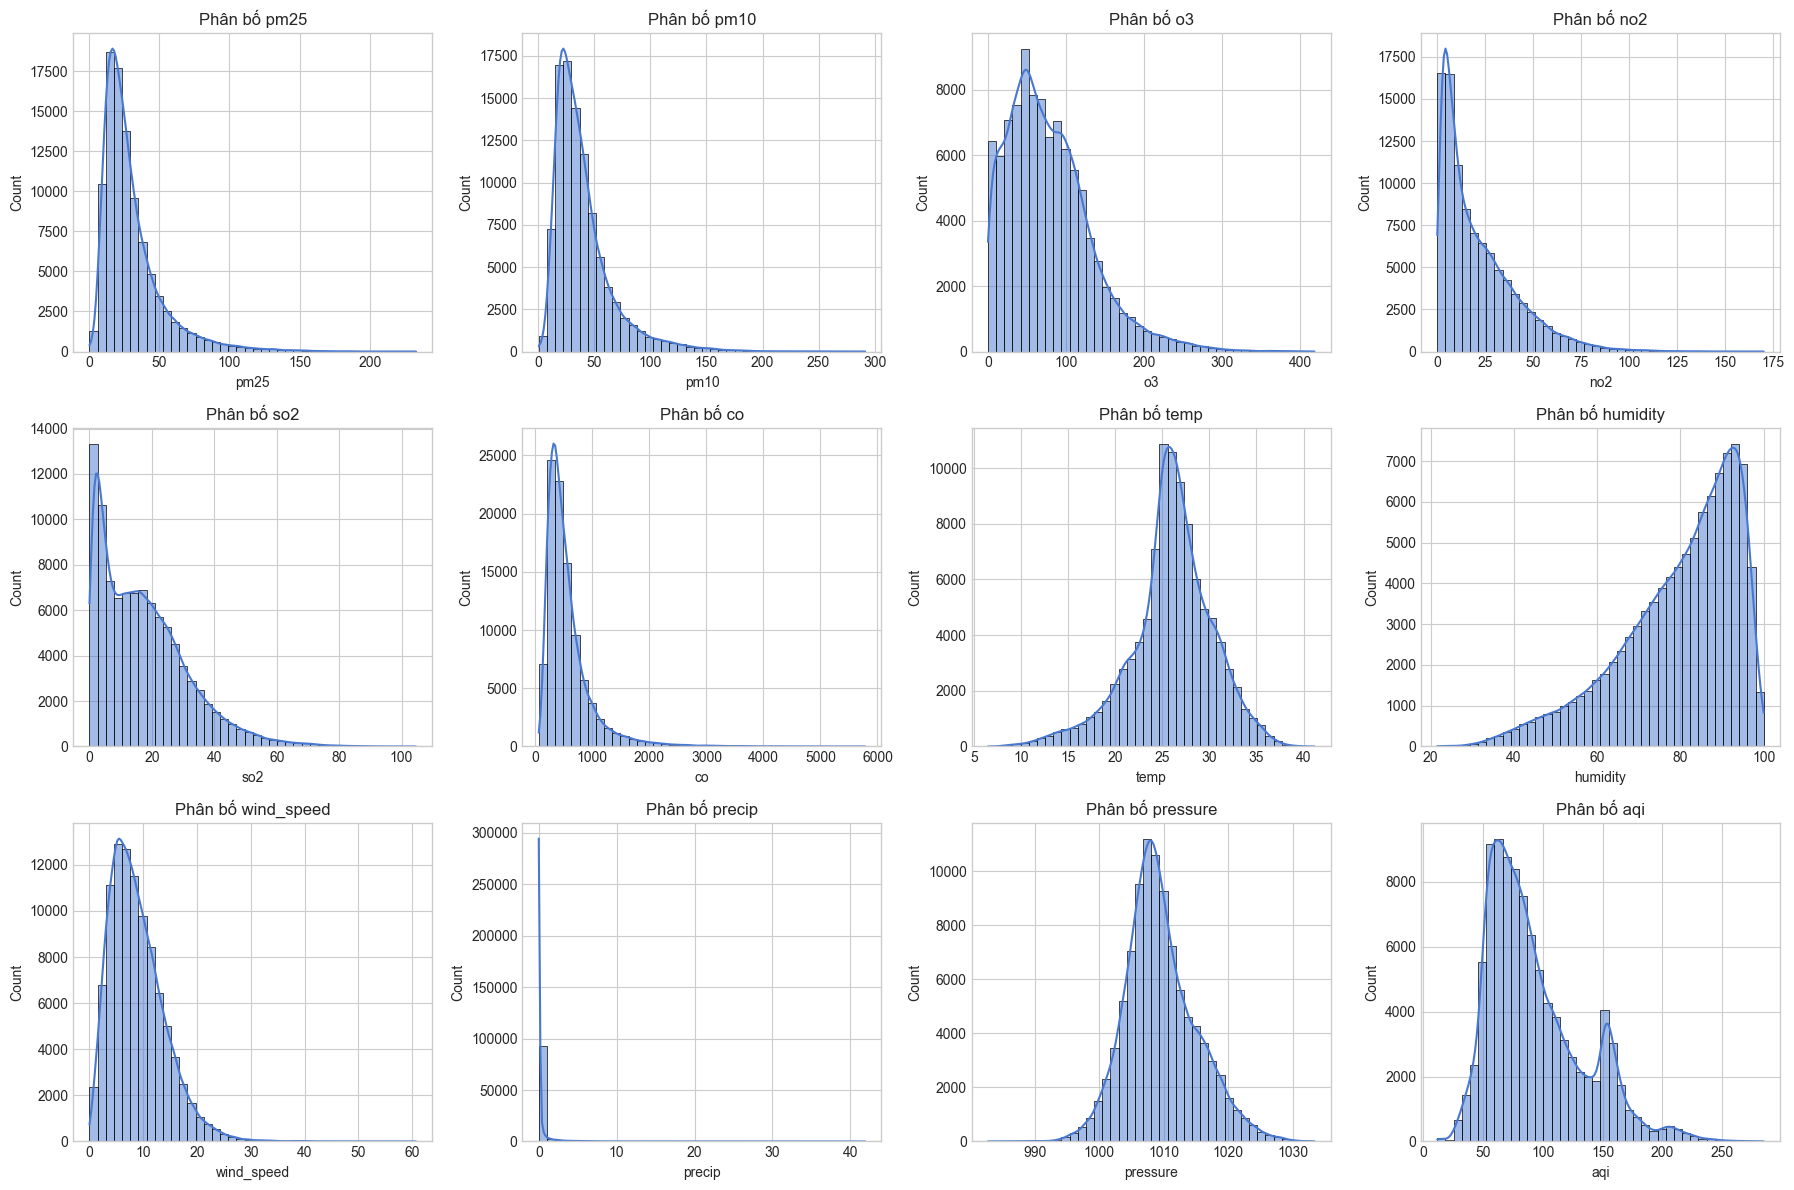

,feature,value,count,percent_%
0,city,Hà Nội,32729,33.33
1,city,TP.HCM,32729,33.33
2,city,Đà Nẵng,32729,33.33
3,season,Khô,34752,35.39
4,season,Mưa,30706,31.27
5,season,Hạ,9497,9.67
6,season,Thu,8736,8.90
7,season,Đông,8664,8.82
8,season,Xuân,5832,5.94
9,aqi_category,Trung bình,57990,59.06


In [49]:
# Phân bố các biến số chính
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()

for ax, col in zip(axes, numerical_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f'Phân bố {col}')
    ax.set_xlabel(col)

for ax in axes[len(numerical_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# Phân bố các biến phân loại
categorical_summary = []
for col in ['city', 'season', 'aqi_category']:
    freq = df[col].value_counts().reset_index()
    freq.columns = ['value', 'count']
    freq['percent_%'] = (freq['count'] / len(df) * 100).round(2)
    freq.insert(0, 'feature', col)
    categorical_summary.append(freq)

categorical_summary = pd.concat(categorical_summary, ignore_index=True)
display(categorical_summary)


<a id='3-2'></a>
### 3.2 Phân tích phân bố nhãn
Kiểm tra phân bố biến mục tiêu hồi quy `aqi` và biến mục tiêu phân loại `aqi_category`, đồng thời đánh giá dữ liệu cân bằng hay mất cân bằng.


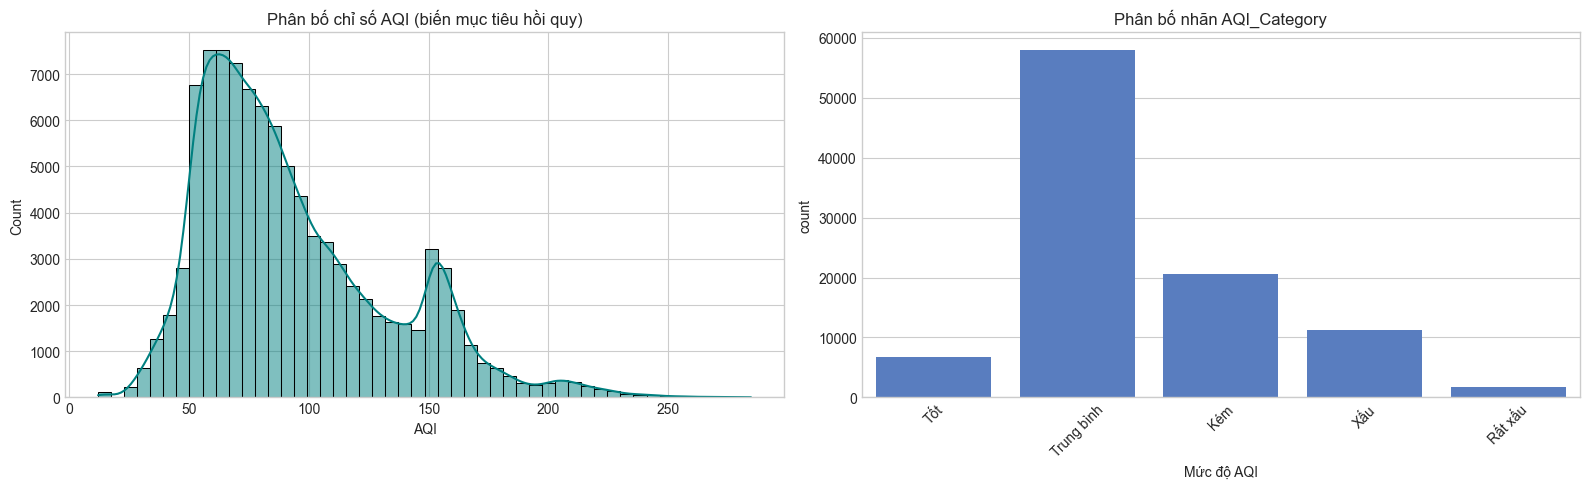

,aqi_category,count,percent_%
0,Trung bình,57990,59.06
1,Kém,20590,20.97
2,Xấu,11174,11.38
3,Tốt,6669,6.79
4,Rất xấu,1764,1.80


Tỷ lệ lớp nhỏ nhất / lớp lớn nhất: 0.030


In [50]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# 1. Phân bố biến liên tục AQI
sns.histplot(df['aqi'], bins=50, kde=True, ax=ax[0], color='teal')
ax[0].set_title('Phân bố chỉ số AQI (biến mục tiêu hồi quy)')
ax[0].set_xlabel('AQI')

# 2. Phân bố nhãn AQI Category
category_order = ["Tốt", "Trung bình", "Kém", "Xấu", "Rất xấu", "Nguy hại"]
present_order = [c for c in category_order if c in df['aqi_category'].unique()]
sns.countplot(data=df, x='aqi_category', order=present_order, ax=ax[1])
ax[1].set_title('Phân bố nhãn AQI_Category')
ax[1].set_xlabel('Mức độ AQI')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

label_distribution = df['aqi_category'].value_counts().rename_axis('aqi_category').reset_index(name='count')
label_distribution['percent_%'] = (label_distribution['count'] / len(df) * 100).round(2)
display(label_distribution)

imbalance_ratio = label_distribution['count'].min() / label_distribution['count'].max()
print(f"Tỷ lệ lớp nhỏ nhất / lớp lớn nhất: {imbalance_ratio:.3f}")


**Nhận xét về phân bổ dữ liệu:**

* **Biến mục tiêu AQI:** phân phối lệch phải; phần lớn giá trị tập trung quanh mức trung bình, còn các giá trị AQI rất cao xuất hiện ít hơn nhưng quan trọng cho cảnh báo sức khỏe.
* **Biến phân loại `aqi_category`:** dữ liệu bị mất cân bằng. Lớp `Trung bình` chiếm khoảng 59%, trong khi `Rất xấu` chỉ khoảng 1.8%.
* **Hệ quả:** mô hình phân loại có thể thiên về lớp phổ biến nếu huấn luyện trực tiếp.
* **Kế hoạch xử lý:** cân nhắc class weights, resampling hoặc đánh giá bằng F1-score/macro-F1 thay vì chỉ accuracy.

<a id='3-3'></a>
### 3.3 Phân tích tương quan & Đa cộng tuyến (Multicollinearity)


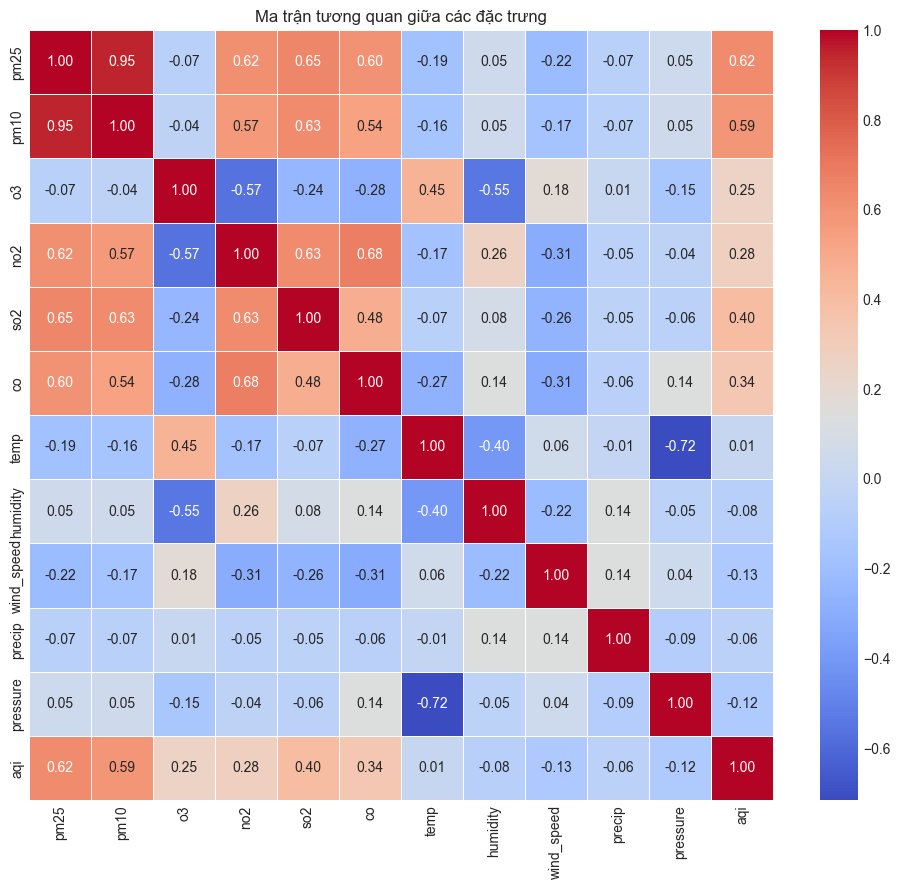

,corr_with_aqi
pm25,0.625
pm10,0.589
so2,0.400
co,0.340
no2,0.276
o3,0.251
wind_speed,-0.132
pressure,-0.115
humidity,-0.076
precip,-0.058


,feature_1,feature_2,correlation,abs_correlation
0,pm25,pm10,0.952,0.952


In [51]:
plt.figure(figsize=(12, 10))
corr_cols = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temp', 'humidity', 'wind_speed', 'precip', 'pressure', 'aqi']
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Ma trận tương quan giữa các đặc trưng")
plt.show()

# Tương quan với biến mục tiêu AQI
target_corr = corr_matrix['aqi'].drop('aqi').sort_values(key=lambda s: s.abs(), ascending=False).to_frame('corr_with_aqi')
display(target_corr.round(3))

# Phát hiện đa cộng tuyến theo tương quan cặp biến
upper_mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
corr_pairs = corr_matrix.where(upper_mask).stack().reset_index()
corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()
high_corr_pairs = corr_pairs[corr_pairs['abs_correlation'] >= 0.80].sort_values('abs_correlation', ascending=False)
display(high_corr_pairs.round(3))


Dựa trên ma trận tương quan, nhóm rút ra các nhận xét sau:

* **Biến có ý nghĩa với AQI:** `pm25` và `pm10` có tương quan thuận lớn nhất với `aqi`; các biến khí như `so2`, `co`, `no2`, `o3` cũng có đóng góp nhất định. Đây là nhóm biến quan trọng cho bài toán dự đoán AQI.
* **Biến khí tượng:** `wind_speed`, `pressure`, `humidity`, `precip`, `temp` có tương quan tuyến tính yếu hơn với AQI, nhưng vẫn có thể hữu ích trong mô hình phi tuyến hoặc theo mùa.
* **Đa cộng tuyến:** cặp `pm25` và `pm10` có tương quan rất cao (khoảng 0.95), cho thấy nguy cơ multicollinearity nếu dùng mô hình tuyến tính. Kế hoạch xử lý là dùng regularization (Ridge/Lasso), mô hình cây, hoặc kiểm tra loại bớt một trong hai biến khi cần giải thích mô hình.


<a id='3-4'></a>
### 3.4 Kiểm tra chất lượng dữ liệu và ngoại lệ
Sử dụng boxplot và quy tắc IQR để phát hiện ngoại lệ, dữ liệu bất thường, dữ liệu không hợp lệ hoặc không đồng nhất.


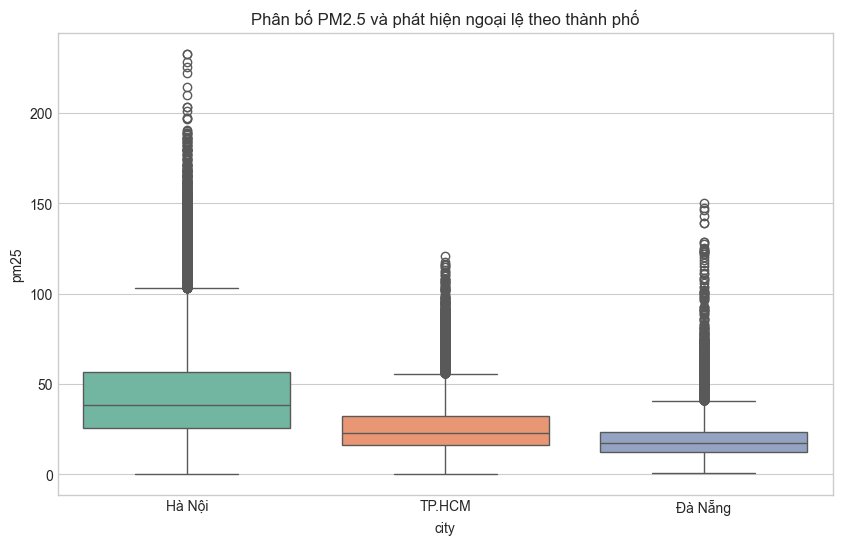

,feature,lower_bound,upper_bound,outlier_count,outlier_percent_%
0,pm25,-15.200,68.000,6089,6.201
1,pm10,-17.275,87.725,5705,5.810
2,o3,-67.000,213.000,2429,2.474
3,no2,-31.575,69.025,2901,2.955
4,so2,-24.300,54.900,1718,1.750
5,co,-243.500,1224.500,6281,6.397
6,aqi,-13.705,192.440,2114,2.153


,check,count
0,o3_negative,0
1,humidity_outside_0_100,0
2,invalid_hour,0
3,duplicate_rows,0
4,missing_values,0


In [52]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='city', y='pm25', palette='Set2')
plt.title("Phân bố PM2.5 và phát hiện ngoại lệ theo thành phố")
plt.show()

# Thống kê outlier theo quy tắc IQR cho một số biến chính
outlier_rows = []
for col in ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'aqi']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        'feature': col,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': count,
        'outlier_percent_%': count / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_rows).round(3)
display(outlier_summary)

# Kiểm tra dữ liệu không hợp lệ sau khi làm sạch
invalid_checks = {
    'o3_negative': int((df['o3'] < 0).sum()),
    'humidity_outside_0_100': int(((df['humidity'] < 0) | (df['humidity'] > 100)).sum()),
    'invalid_hour': int(((df['hour'] < 0) | (df['hour'] > 23)).sum()),
    'duplicate_rows': int(df.duplicated().sum()),
    'missing_values': int(df.isnull().sum().sum())
}
display(pd.DataFrame(list(invalid_checks.items()), columns=['check', 'count']))


**Nhận xét và kế hoạch xử lý:**
- Boxplot cho thấy PM2.5 có nhiều outlier, đặc biệt ở Hà Nội. Đây thường là các thời điểm ô nhiễm cao, có ý nghĩa thực tế với bài toán cảnh báo.
- Các outlier theo IQR được ghi nhận trong bảng để phục vụ phân tích, nhưng không xóa tự động vì có thể làm mất các đợt ô nhiễm nghiêm trọng.
- Dữ liệu không hợp lệ sau làm sạch được kiểm tra lại: không còn O3 âm, không còn missing, không có duplicate và các biến thời gian nằm trong phạm vi hợp lệ.
- Kế hoạch xử lý ở bước mô hình: giữ outlier, dùng mô hình bền vững với ngoại lệ hoặc biến đổi log/robust scaling nếu mô hình tuyến tính bị ảnh hưởng.


<a id='3-5'></a>
### 3.5 EDA cho dữ liệu phi cấu trúc

Bộ dữ liệu của đề tài là **dữ liệu có cấu trúc dạng bảng** (`CSV`) gồm biến thời gian, biến số và biến phân loại. Dataset không chứa ảnh, văn bản tự do hoặc âm thanh, nên các bước EDA phi cấu trúc sau **không áp dụng trực tiếp**:

| Loại dữ liệu phi cấu trúc | Trạng thái trong đề tài | Lý do |
|---|---|---|
| Ảnh | Không áp dụng | Không có file ảnh, độ phân giải, độ sáng/tối hay đối tượng trong ảnh. |
| Văn bản | Không áp dụng | Không có câu/tài liệu tự do; các cột `city`, `season`, `aqi_category` là biến phân loại có cấu trúc. |
| Âm thanh | Không áp dụng | Không có tín hiệu âm thanh để phân tích phổ. |

Nếu đề tài mở rộng thêm dữ liệu camera giao thông, tin tức, bài đăng mạng xã hội hoặc âm thanh môi trường, nhóm sẽ bổ sung EDA tương ứng như thống kê độ phân giải ảnh, độ dài văn bản, tần suất từ khóa, tỷ lệ nhiễu/ký tự đặc biệt hoặc phổ âm thanh.


<a id='4'></a>
## 4. Tiền xử lý dữ liệu cho Mô hình Học máy

<a id='4-1'></a>
### 4.1 Feature Engineering & Encode Categorical
* **One-hot Encoding:** áp dụng cho biến phân loại đầu vào `city`, `season`.
* **Label Encoding:** ánh xạ biến mục tiêu phân loại `aqi_category` từ nhãn tiếng Việt sang số.
* **Sắp xếp thời gian:** trước khi chia train/validation/test, dữ liệu được sắp xếp theo `datetime` và `city` để hạn chế rò rỉ tương lai về quá khứ.
* Loại bỏ `datetime` sau khi đã trích xuất các thuộc tính thời gian.


In [53]:
# Sắp xếp theo thời gian trước khi encode và chia tập
# Sau bước imputation, df đang được sort theo city + datetime để xử lý từng chuỗi riêng.
df_model = df.sort_values(['datetime', 'city']).reset_index(drop=True)

# One-hot encode cho biến phân loại đầu vào
df_encoded = pd.get_dummies(df_model, columns=['city', 'season'], drop_first=False)

# Chuyển đổi aqi_category tiếng Việt sang dạng số
category_mapping = {
    'Tốt': 0,
    'Trung bình': 1,
    'Kém': 2,
    'Xấu': 3,
    'Rất xấu': 4,
    'Nguy hại': 5
}
df_encoded['aqi_category_encoded'] = df_encoded['aqi_category'].map(category_mapping)

missing_encoded = df_encoded['aqi_category_encoded'].isnull().sum()
print(f"Số nhãn aqi_category không map được: {missing_encoded}")
print("Phân bố nhãn encoded:")
print(df_encoded['aqi_category_encoded'].value_counts().sort_index())

# Tách biến
features_to_drop = ['datetime', 'eu_aqi', 'aqi_category', 'aqi', 'aqi_category_encoded']
X = df_encoded.drop(columns=features_to_drop)

# Target 1 (Hồi quy)
y_reg = df_encoded['aqi']

# Target 2 (Phân loại)
y_clf = df_encoded['aqi_category_encoded']


Số nhãn aqi_category không map được: 0
Phân bố nhãn encoded:
aqi_category_encoded
0     6669
1    57990
2    20590
3    11174
4     1764
Name: count, dtype: int64


<a id='4-2'></a>
### 4.2 Train/Val/Test Split (Time-Series)
Do bản chất là dữ liệu chuỗi thời gian, không sử dụng `train_test_split` ngẫu nhiên vì có thể gây rò rỉ dữ liệu từ tương lai về quá khứ. Dữ liệu được sắp xếp theo thời gian và chia tuần tự:
* **Train:** 70% dữ liệu cũ nhất
* **Validation:** 15% tiếp theo
* **Test:** 15% mới nhất


In [54]:
# Split by unique datetime values so all cities at the same observed hour
# stay in the same train/validation/test partition.
unique_times = pd.Series(df_model['datetime'].sort_values().unique())
train_time_cut = unique_times.iloc[int(len(unique_times) * 0.70)]
val_time_cut = unique_times.iloc[int(len(unique_times) * 0.85)]

train_mask = df_model['datetime'] < train_time_cut
val_mask = (df_model['datetime'] >= train_time_cut) & (df_model['datetime'] < val_time_cut)
test_mask = df_model['datetime'] >= val_time_cut

X_train, y_train_reg, y_train_clf = X.loc[train_mask], y_reg.loc[train_mask], y_clf.loc[train_mask]
X_val, y_val_reg, y_val_clf = X.loc[val_mask], y_reg.loc[val_mask], y_clf.loc[val_mask]
X_test, y_test_reg, y_test_clf = X.loc[test_mask], y_reg.loc[test_mask], y_clf.loc[test_mask]

print(f"Train shape: {X_train.shape}")
print(f"Val shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")
print("\nTime range by partition:")
print(f"Train: {df_model.loc[train_mask, 'datetime'].min()} -> {df_model.loc[train_mask, 'datetime'].max()}")
print(f"Val  : {df_model.loc[val_mask, 'datetime'].min()} -> {df_model.loc[val_mask, 'datetime'].max()}")
print(f"Test : {df_model.loc[test_mask, 'datetime'].min()} -> {df_model.loc[test_mask, 'datetime'].max()}")


Train shape: (68730, 37)
Val shape: (14727, 37)
Test shape: (14730, 37)

Time range by partition:
Train: 2022-08-05 07:00:00 -> 2025-03-16 20:00:00
Val  : 2025-03-16 21:00:00 -> 2025-10-07 09:00:00
Test : 2025-10-07 10:00:00 -> 2026-04-29 23:00:00


<a id='4-3'></a>
### 4.3 Chuẩn hóa dữ liệu (Scaling)
Áp dụng `StandardScaler` cho các biến liên tục. Chú ý chỉ fit trên tập Train để tránh rò rỉ dữ liệu.

In [55]:
from sklearn.preprocessing import StandardScaler

# Chỉ scale những cột numeric, bỏ qua các cột đã one-hot encoded
numeric_features = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temp', 'humidity', 
                    'wind_speed', 'precip', 'pressure', 'cloud_cover', 
                    'pm25_lag_1h', 'pm25_lag_3h', 'pm25_lag_6h', 'pm25_lag_12h', 'pm25_lag_24h', 
                    'pm25_roll_6h', 'pm25_roll_24h', 'pm25_roll_72h']

scaler = StandardScaler()

# Cần đảm bảo copy để không warning SettingWithCopy
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val_scaled[numeric_features] = scaler.transform(X_val[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Đã hoàn tất quá trình chuẩn hóa. Dữ liệu sẵn sàng cho bước Xây dựng mô hình.")

Đã hoàn tất quá trình chuẩn hóa. Dữ liệu sẵn sàng cho bước Xây dựng mô hình.
